# LIMUC VLM LoRA fine-tuning (optional)
Fine-tune a vision-language model with LoRA to predict MES scores.
Output format: `SCORE: X`.


In [1]:
import sys, site
print(sys.executable)
print(site.getsitepackages())


import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"
os.environ["TRANSFORMERS_NO_JAX"] = "1"
os.environ["USE_TF"] = "0"

import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset

from transformers import AutoProcessor, TrainingArguments, Trainer
try:
    from transformers import AutoModelForVision2Seq
    _HAS_VISION2SEQ = True
except Exception:
    from transformers import Blip2ForConditionalGeneration
    AutoModelForVision2Seq = None
    _HAS_VISION2SEQ = False

try:
    from peft import LoraConfig, get_peft_model
    _HAS_PEFT = True
except Exception as e:
    _HAS_PEFT = False
    print("Missing dependency: peft")
    print("Install with: pip install peft  (or conda install -c conda-forge peft)")
    raise


/home/arcturus/miniforge3/envs/vlm-lora-gpu/bin/python
['/home/arcturus/miniforge3/envs/vlm-lora-gpu/lib/python3.11/site-packages']


/home/arcturus/miniforge3/envs/vlm-lora-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths & config
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root containing '0_dataset_prep'. cwd={start}")

DATA_ROOT = find_dataset_root()
META_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "metadata_enriched.csv"
LABEL_MAP_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "label_map.csv"
RUN_NAME = os.getenv("RUN_NAME", "vlm_lora_finetune_mayo")
OUT_DIR = DATA_ROOT / "3_vlm_severity" / "results" / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)
ADAPTER_DIR = OUT_DIR / "lora_adapter"

MODEL_NAME = os.getenv("VLM_MODEL", "Salesforce/blip2-flan-t5-xl")
FORCE_CUDA = int(os.getenv("FORCE_CUDA", "1"))
if FORCE_CUDA and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available in this Python environment. "
        "Install a CUDA-enabled PyTorch build and restart the kernel."
    )
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
MODEL_DTYPE = torch.bfloat16 if USE_BF16 else (torch.float16 if torch.cuda.is_available() else None)
if DEVICE.type == "cuda":
    torch.cuda.set_device(0)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

SEED = int(os.getenv("SEED", "42"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "2"))
GRAD_ACCUM = int(os.getenv("GRAD_ACCUM", "4"))
EPOCHS = int(os.getenv("EPOCHS", "3"))
LR = float(os.getenv("LR", "5e-5"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "0.0"))
MAX_SAMPLES = int(os.getenv("MAX_SAMPLES", "0")) or None

# LoRA params
LORA_R = int(os.getenv("LORA_R", "8"))
LORA_ALPHA = int(os.getenv("LORA_ALPHA", "16"))
LORA_DROPOUT = float(os.getenv("LORA_DROPOUT", "0.1"))

PROMPT = (
    "You are a medical expert. Given this colonoscopy image, provide the Mayo Endoscopic Score (0-3). "
    "Respond with only: 'SCORE: X' where X is 0,1,2, or 3."
)

print("Model:", MODEL_NAME)
print("Run name:", RUN_NAME)
print("Output dir:", OUT_DIR)



Using GPU: NVIDIA GeForce RTX 3090
Model: Salesforce/blip2-flan-t5-xl
Run name: vlm_lora_finetune_mayo
Output dir: /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/LIMUC/3_vlm_severity/results/vlm_lora_finetune_mayo


In [3]:
# Seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load metadata
meta = pd.read_csv(META_CSV)
images_base = DATA_ROOT / "0_dataset_prep"

def to_abs(p):
    p = Path(p)
    if p.is_absolute():
        return p
    return (images_base / p).resolve()

meta["image_path"] = meta["image_path"].apply(lambda p: str(to_abs(p)))

if LABEL_MAP_CSV.exists():
    label_map = pd.read_csv(LABEL_MAP_CSV)
    id_to_name = dict(zip(label_map.label_id, label_map.label_name))
else:
    id_to_name = {i: name for i, name in enumerate(sorted(meta.label_name.unique()))}

name_to_id = {v: k for k, v in id_to_name.items()}
meta["label_id"] = meta["label_name"].map(name_to_id)

meta = meta[meta["image_path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)
if MAX_SAMPLES:
    meta = meta.sample(n=min(MAX_SAMPLES, len(meta)), random_state=SEED).reset_index(drop=True)

train_df = meta[meta["split"] == "train"].reset_index(drop=True)
val_df = meta[meta["split"].isin(["val", "validation"])].reset_index(drop=True)
test_df = meta[meta["split"] == "test"].reset_index(drop=True)

print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))


Train/Val/Test: 8669 921 1686


In [4]:
processor = AutoProcessor.from_pretrained(MODEL_NAME)

# Use bf16 if supported, else fp16 on GPU to reduce memory footprint
if MODEL_DTYPE is not None:
    if _HAS_VISION2SEQ:
        model = AutoModelForVision2Seq.from_pretrained(MODEL_NAME, torch_dtype=MODEL_DTYPE)
    else:
        model = Blip2ForConditionalGeneration.from_pretrained(MODEL_NAME, torch_dtype=MODEL_DTYPE)
else:
    if _HAS_VISION2SEQ:
        model = AutoModelForVision2Seq.from_pretrained(MODEL_NAME)
    else:
        model = Blip2ForConditionalGeneration.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)

# Infer LoRA target modules (best effort)
def infer_lora_targets(module):
    candidates = {"q_proj", "v_proj", "k_proj", "o_proj", "q", "v", "k", "o", "fc1", "fc2", "dense"}
    found = set()
    for name, sub in module.named_modules():
        if isinstance(sub, torch.nn.Linear):
            suffix = name.split(".")[-1]
            if suffix in candidates:
                found.add(suffix)
    if not found:
        return ["q_proj", "v_proj"]
    return sorted(found)

# Apply LoRA to the language model only (avoids inputs_embeds kwargs clash in BLIP2)
if not hasattr(model, "language_model"):
    raise RuntimeError("Expected BLIP2 model with a language_model attribute; got: " + model.__class__.__name__)

lm = model.language_model

target_modules = infer_lora_targets(lm)
print("LoRA target modules (language_model):", target_modules)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=target_modules,
    bias="none",
    task_type="SEQ_2_SEQ_LM",
)

model.language_model = get_peft_model(lm, lora_config)
model.language_model.print_trainable_parameters()
print("DEVICE:", DEVICE)
print("model.device:", model.device)



The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 1289/1289 [00:01<00:00, 681.11it/s, Materializing param=vision_model.post_layernorm.weight]                                                
The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 23.54 GiB of which 23.88 MiB is free. Process 567450 has 638.00 MiB memory in use. Process 573855 has 2.18 GiB memory in use. Process 590241 has 3.80 GiB memory in use. Process 599656 has 8.25 GiB memory in use. Including non-PyTorch memory, this process has 7.79 GiB memory in use. Of the allocated memory 6.88 GiB is allocated by PyTorch, and 675.91 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
class VQADataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.image_path).convert("RGB")
        prompt = PROMPT
        target = f"SCORE: {row.label_id}"
        inputs = processor(images=img, text=prompt, return_tensors="pt")
        # Some processor versions may include inputs_embeds; remove to avoid double-passing.
        if "inputs_embeds" in inputs:
            inputs.pop("inputs_embeds")
        labels = processor.tokenizer(target, return_tensors="pt").input_ids
        labels[labels == processor.tokenizer.pad_token_id] = -100
        item = {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "input_ids": inputs["input_ids"].squeeze(0),
            "labels": labels.squeeze(0),
        }
        if "attention_mask" in inputs:
            item["attention_mask"] = inputs["attention_mask"].squeeze(0)
        return item


def collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])
    input_ids = torch.nn.utils.rnn.pad_sequence(
        [b["input_ids"] for b in batch], batch_first=True, padding_value=processor.tokenizer.pad_token_id
    )
    labels = torch.nn.utils.rnn.pad_sequence(
        [b["labels"] for b in batch], batch_first=True, padding_value=-100
    )
    result = {
        "pixel_values": pixel_values,
        "input_ids": input_ids,
        "labels": labels,
    }
    if "attention_mask" in batch[0] and batch[0]["attention_mask"] is not None:
        attention_mask = torch.nn.utils.rnn.pad_sequence(
            [b["attention_mask"] for b in batch], batch_first=True, padding_value=0
        )
        result["attention_mask"] = attention_mask
    return result


In [ ]:
train_ds = VQADataset(train_df)
val_ds = VQADataset(val_df)

args = TrainingArguments(
    output_dir=str(OUT_DIR / "checkpoints"),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    logging_steps=25,
    save_steps=200,
    save_total_limit=2,
    fp16=False,
    bf16=USE_BF16,
    report_to="none",
)

class SafeTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Avoid duplicate kwargs and unsupported extras in older Transformers
        inputs = dict(inputs)
        inputs.pop("inputs_embeds", None)
        inputs.pop("decoder_inputs_embeds", None)
        inputs.pop("num_items_in_batch", None)
        kwargs.pop("num_items_in_batch", None)
        outputs = model(**inputs)
        loss = outputs["loss"] if isinstance(outputs, dict) else outputs[0]
        return (loss, outputs) if return_outputs else loss

trainer = SafeTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
)

train_result = trainer.train()

# Persist training history and summary for traceability.
history_df = pd.DataFrame(trainer.state.log_history)
history_df.to_csv(OUT_DIR / "training_history.csv", index=False)
training_summary = {
    "global_step": int(getattr(trainer.state, "global_step", 0) or 0),
    "best_metric": float(trainer.state.best_metric) if trainer.state.best_metric is not None else None,
    "best_model_checkpoint": trainer.state.best_model_checkpoint,
    "train_runtime": train_result.metrics.get("train_runtime"),
    "train_samples_per_second": train_result.metrics.get("train_samples_per_second"),
    "train_steps_per_second": train_result.metrics.get("train_steps_per_second"),
    "train_loss": train_result.metrics.get("train_loss"),
}
with open(OUT_DIR / "training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=2)

# Persist adapter weights explicitly from PEFT language model.
ADAPTER_DIR.mkdir(parents=True, exist_ok=True)
if hasattr(model, "language_model") and hasattr(model.language_model, "save_pretrained"):
    model.language_model.save_pretrained(ADAPTER_DIR, safe_serialization=True)
else:
    model.save_pretrained(ADAPTER_DIR, safe_serialization=True)

# Save processor to keep eval fully reproducible.
processor.save_pretrained(ADAPTER_DIR)

# Save LoRA config and parameter counts as proof artifacts.
peft_config = {}
if hasattr(model, "language_model") and hasattr(model.language_model, "peft_config"):
    for key, cfg in model.language_model.peft_config.items():
        if hasattr(cfg, "to_dict"):
            peft_config[str(key)] = cfg.to_dict()
        else:
            peft_config[str(key)] = {"repr": repr(cfg)}
with open(OUT_DIR / "lora_config.json", "w") as f:
    json.dump(peft_config, f, indent=2)

TOTAL_PARAMS = int(sum(p.numel() for p in model.parameters()))
TRAINABLE_PARAMS = int(sum(p.numel() for p in model.parameters() if p.requires_grad))
LORA_PARAM_COUNTS = {
    "total_params": TOTAL_PARAMS,
    "trainable_params": TRAINABLE_PARAMS,
    "trainable_pct": float(100.0 * TRAINABLE_PARAMS / max(TOTAL_PARAMS, 1)),
}
with open(OUT_DIR / "lora_param_count.json", "w") as f:
    json.dump(LORA_PARAM_COUNTS, f, indent=2)

adapter_weight_files = sorted(ADAPTER_DIR.glob("adapter_model.*"))
if adapter_weight_files:
    print("Saved adapter weights:", [p.name for p in adapter_weight_files])
else:
    print("WARNING: adapter_model weights not found under", ADAPTER_DIR)



Step,Training Loss
25,38.739912
50,36.894551
75,35.270137
100,33.136089
125,30.943586
150,28.969851
175,27.324980
200,26.010305
225,24.763362
250,23.744368


Writing model shards: 100%|██████████| 1/1 [00:23<00:00, 23.07s/it]


In [ ]:
# Inference on val/test
model.eval()

def parse_score(text: str):
    if text is None:
        return None
    m = re.search(r"\b(?:SCORE\s*:\s*)?([0-3])\b", text, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))
    return None

def run_split(df: pd.DataFrame):
    y_true, y_pred = [], []
    preds_text = []
    for row in df.itertuples(index=False):
        img = Image.open(row.image_path).convert("RGB")
        inputs = processor(images=img, text=PROMPT, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            generated = model.generate(
                **inputs,
                max_new_tokens=8,
                do_sample=False,
            )
        text = processor.batch_decode(generated, skip_special_tokens=True)[0]
        score = parse_score(text)
        y_true.append(int(row.label_id))
        y_pred.append(score if score is not None else -1)
        preds_text.append(text)
    return np.array(y_true), np.array(y_pred), preds_text


In [ ]:
# =====================
# Metrics helpers
# =====================
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)

try:
    from scipy.stats import spearmanr
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


def expected_calibration_error(y_true, y_prob, n_bins=10):
    if y_prob is None:
        return None
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i + 1])
        if mask.any():
            ece += abs(accuracies[mask].mean() - confidences[mask].mean()) * mask.mean()
    return float(ece)


def compute_metrics(y_true, y_pred, labels, label_names, y_prob=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )

    valid_mask = np.isin(y_pred, labels)
    summary = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
        "qwk": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "parse_rate": float(valid_mask.mean()) if len(valid_mask) else 0.0,
    }

    if _HAS_SCIPY:
        summary["spearman"] = float(spearmanr(y_true, y_pred).correlation)

    if y_prob is not None:
        try:
            summary["auroc_ovr"] = float(roc_auc_score(y_true, y_prob, multi_class="ovr"))
        except Exception:
            summary["auroc_ovr"] = None
        summary["ece"] = expected_calibration_error(y_true, y_prob, n_bins=10)

    return summary, report


def save_split_outputs(
    split_name,
    y_true,
    y_pred,
    labels,
    label_names,
    out_dir,
    y_prob=None,
    df_meta=None,
    raw_texts=None,
):
    summary, report = compute_metrics(y_true, y_pred, labels, label_names, y_prob)

    # Save metrics
    metrics = {
        "split": split_name,
        "summary": summary,
        "report": report,
    }
    with open(out_dir / f"metrics_{split_name}.json", "w") as f:
        json.dump(metrics, f, indent=2)

    # Save per-class report
    per_class = {k: v for k, v in report.items() if k in label_names}
    pd.DataFrame(per_class).T.to_csv(out_dir / f"per_class_{split_name}.csv")

    # Save predictions
    pred_df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
    })
    if df_meta is not None:
        pred_df["img_id"] = df_meta["img_id"].values
        pred_df["image_path"] = df_meta["image_path"].values
    if raw_texts is not None:
        pred_df["raw_text"] = list(raw_texts)
    if y_prob is not None:
        for i, name in enumerate(label_names):
            pred_df[f"prob_{name}"] = y_prob[:, i]
    pred_df.to_csv(out_dir / f"pred_{split_name}.csv", index=False)

    return summary, report



Saved outputs not found; running inference + metrics...


/tmp/ipykernel_1704020/2267876748.py:64: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  summary["spearman"] = float(spearmanr(y_true, y_pred).correlation)
/tmp/ipykernel_1704020/2267876748.py:64: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  summary["spearman"] = float(spearmanr(y_true, y_pred).correlation)


Val summary:
{
  "accuracy": 0.5266015200868621,
  "balanced_accuracy": 0.25,
  "macro_f1": 0.172475106685633,
  "weighted_f1": 0.3633026134311922,
  "qwk": 0.0,
  "mae": 0.7709011943539631,
  "rmse": 1.2460578445676935,
  "spearman": NaN
}
Test summary:
{
  "accuracy": 0.5486358244365361,
  "balanced_accuracy": 0.25,
  "macro_f1": 0.17713519724243584,
  "weighted_f1": 0.38873085990332895,
  "qwk": 0.0,
  "mae": 0.6986951364175563,
  "rmse": 1.1557273954415634,
  "spearman": NaN
}

Confusion (val):


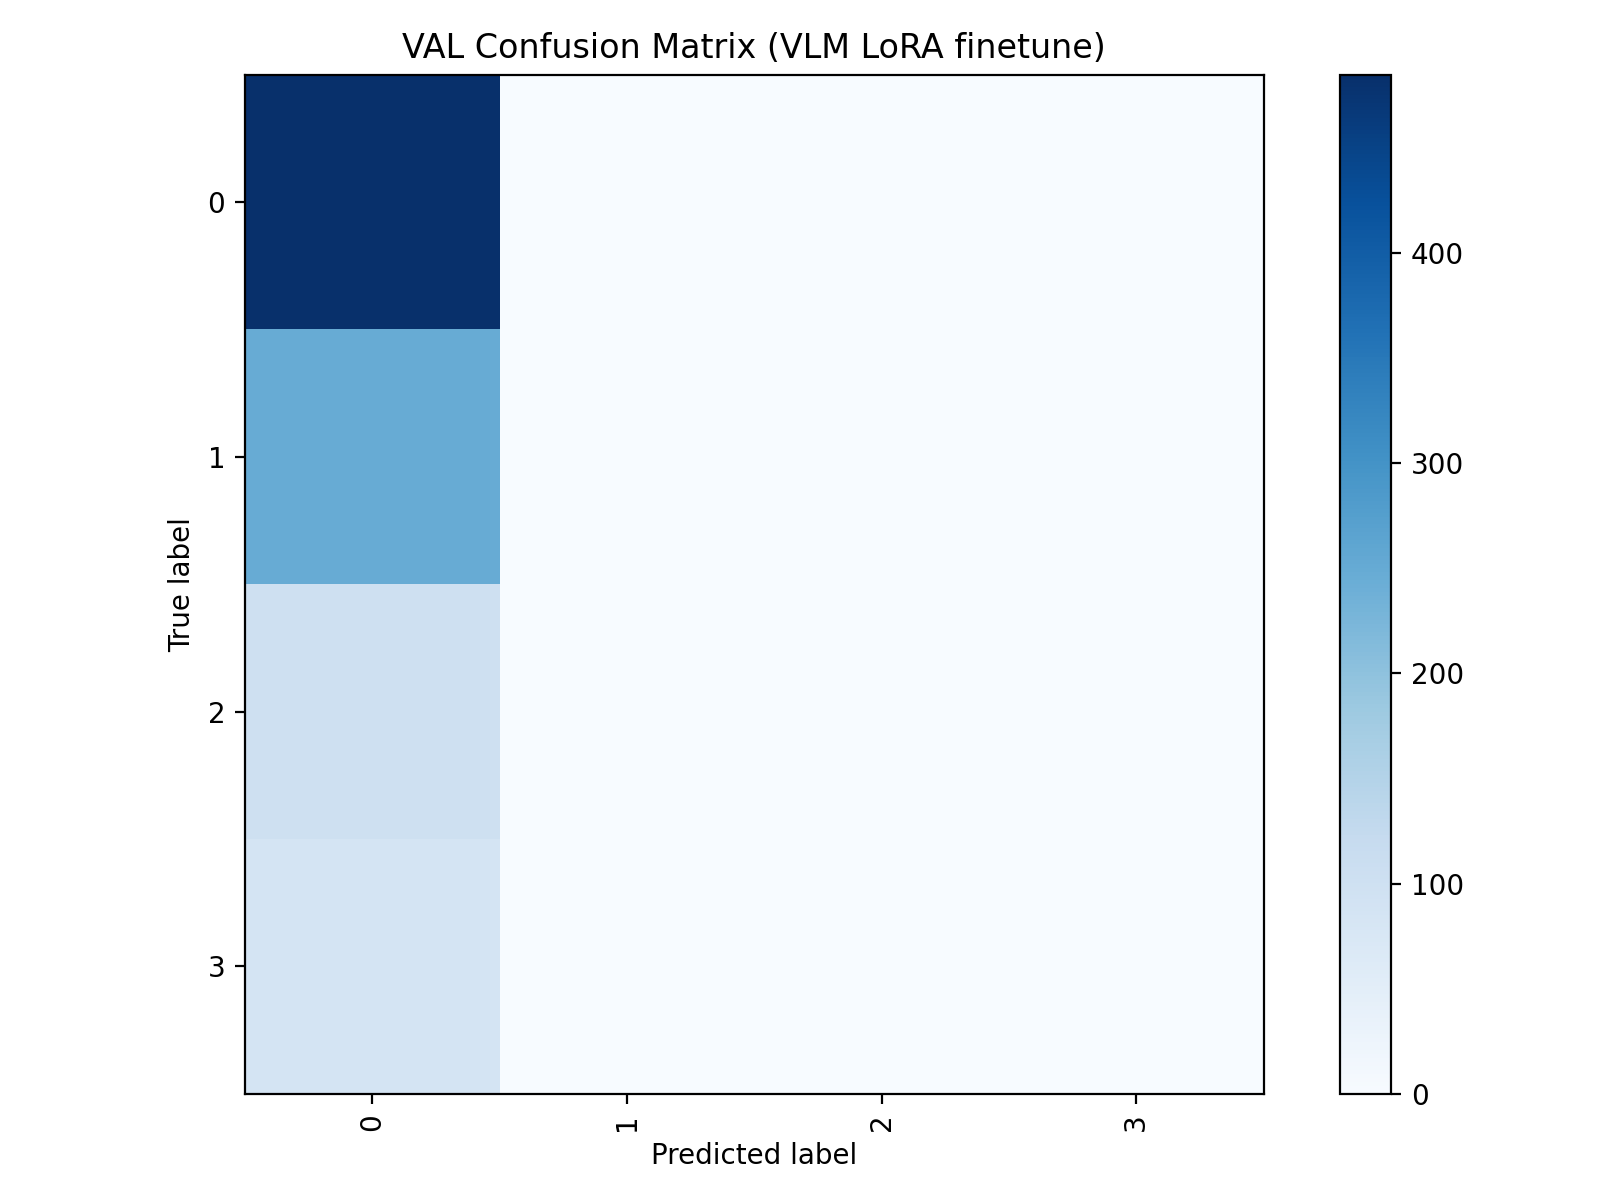


Confusion (test):


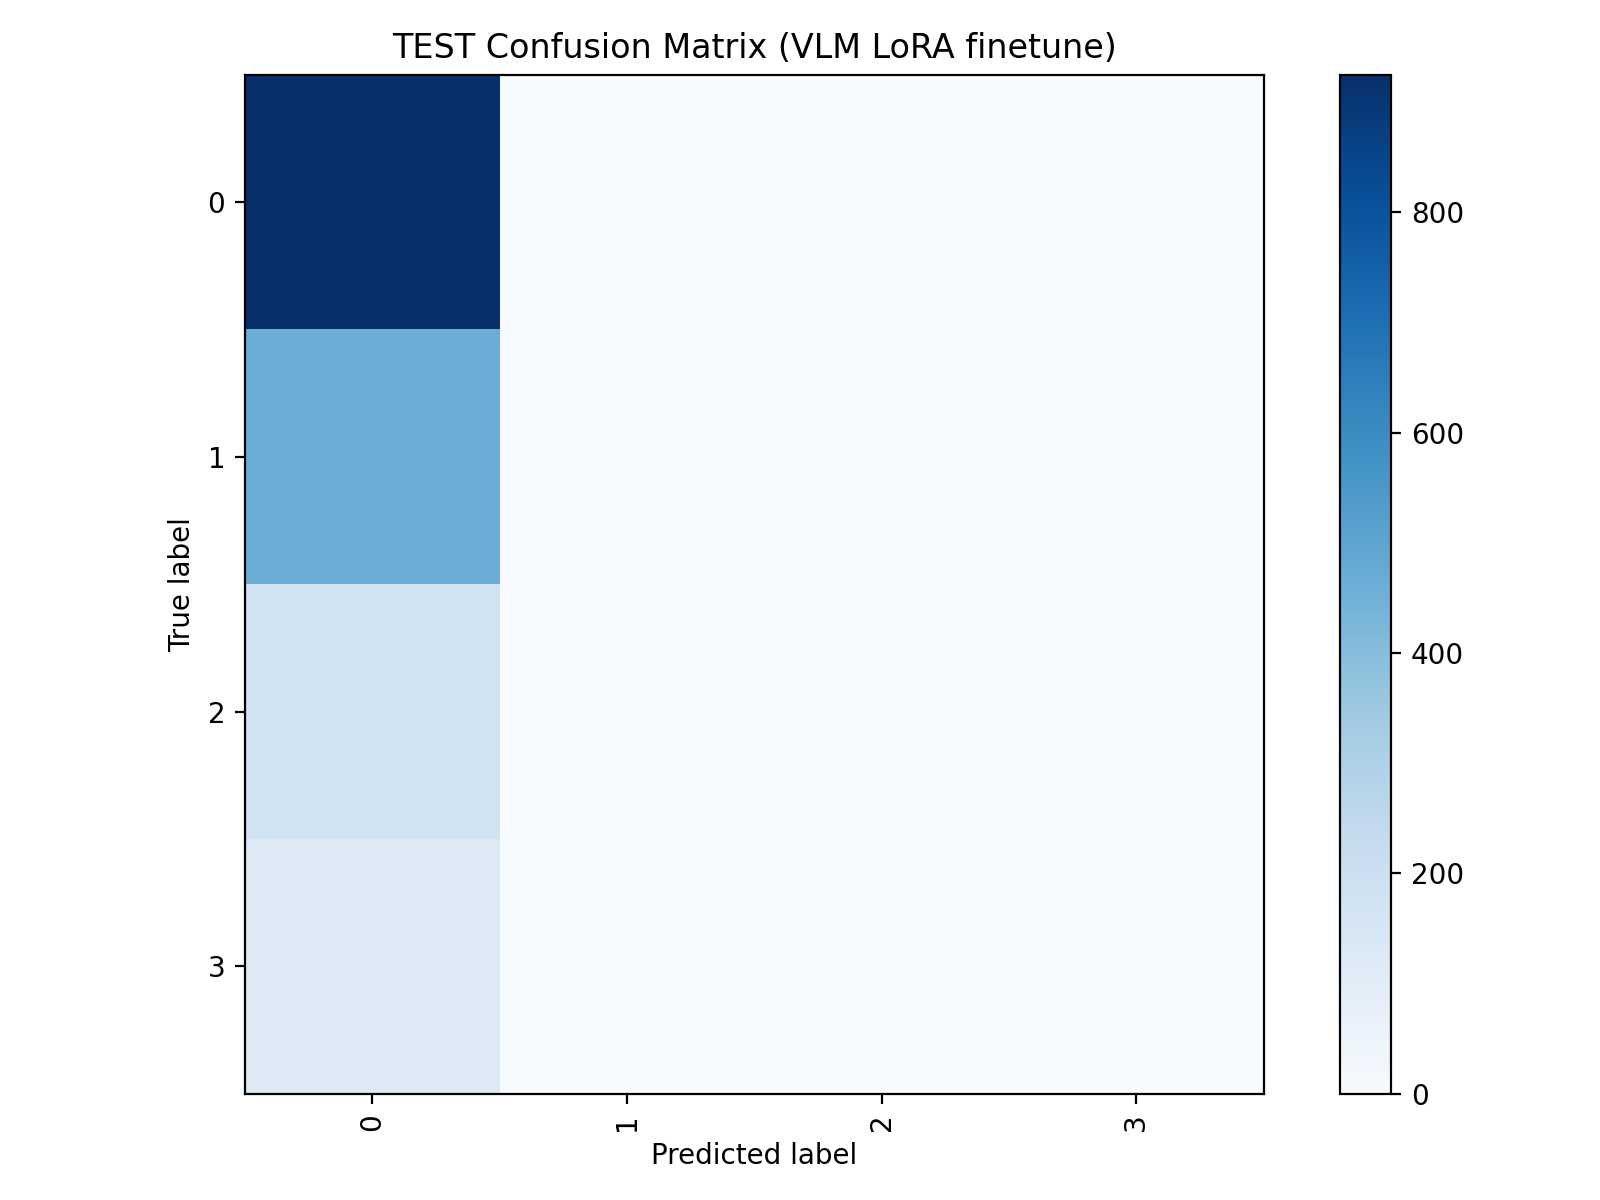

Saved outputs to /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/LIMUC/3_vlm_severity/results/vlm_lora_finetune_mayo


In [ ]:
# =====================
# Results (load if already saved; otherwise compute + save)
# =====================
from pathlib import Path

labels = sorted(id_to_name.keys())
label_names = [id_to_name[i] for i in labels]

pred_val_path = OUT_DIR / "pred_val.csv"
pred_test_path = OUT_DIR / "pred_test.csv"
metrics_val_path = OUT_DIR / "metrics_val.json"
metrics_test_path = OUT_DIR / "metrics_test.json"
conf_val_path = OUT_DIR / "confusion_val.npy"
conf_test_path = OUT_DIR / "confusion_test.npy"


def _load_json(path: Path):
    if path.exists():
        return json.loads(path.read_text())
    return None


def _print_summary(name, metrics_json):
    if not metrics_json:
        print(f"{name} summary: <missing>")
        return
    print(f"{name} summary:")
    print(json.dumps(metrics_json.get("summary", {}), indent=2))


if pred_val_path.exists() and pred_test_path.exists() and metrics_val_path.exists() and metrics_test_path.exists():
    # Fast path: just load and display
    val_metrics = _load_json(metrics_val_path)
    test_metrics = _load_json(metrics_test_path)

    _print_summary("Val", val_metrics)
    _print_summary("Test", test_metrics)

    print("")
    print("Pred files:")
    print(" -", pred_val_path)
    print(" -", pred_test_path)
else:
    # Compute and save (requires model + processor loaded)
    if "run_split" not in globals():
        raise RuntimeError(
            "Saved outputs not found and run_split is undefined. "
            "Run the inference cell (the one that defines run_split) once, or re-run training."
        )
    if "val_df" not in globals() or "test_df" not in globals():
        raise RuntimeError("val_df/test_df are not defined. Run the data loading cells first.")

    print("Saved outputs not found; running inference + metrics...")
    y_val, pred_val, text_val = run_split(val_df)
    y_test, pred_test, text_test = run_split(test_df)

    # Metrics + predictions
    val_summary, _ = save_split_outputs(
        "val", y_val, pred_val, labels, label_names, OUT_DIR, y_prob=None, df_meta=val_df, raw_texts=text_val
    )
    test_summary, _ = save_split_outputs(
        "test", y_test, pred_test, labels, label_names, OUT_DIR, y_prob=None, df_meta=test_df, raw_texts=text_test
    )

    # Also persist raw generations for parser audit workflows.
    pd.DataFrame({"y_true": y_val, "y_pred": pred_val, "raw_text": text_val}).to_csv(
        OUT_DIR / "pred_val_raw.csv", index=False
    )
    pd.DataFrame({"y_true": y_test, "y_pred": pred_test, "raw_text": text_test}).to_csv(
        OUT_DIR / "pred_test_raw.csv", index=False
    )

    print("Val summary:")
    print(json.dumps(val_summary, indent=2))
    print("Test summary:")
    print(json.dumps(test_summary, indent=2))

    # Confusion matrices
    val_cm = confusion_matrix(y_val, pred_val, labels=labels)
    test_cm = confusion_matrix(y_test, pred_test, labels=labels)
    np.save(conf_val_path, val_cm)
    np.save(conf_test_path, test_cm)

    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    for split_name, cm in [("val", val_cm), ("test", test_cm)]:
        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
        disp.plot(include_values=False, cmap="Blues", ax=ax, xticks_rotation=90)
        plt.title(f"{split_name.upper()} Confusion Matrix (VLM LoRA finetune)")
        plt.tight_layout()
        fig_path = OUT_DIR / f"confusion_{split_name}.png"
        plt.savefig(fig_path, dpi=200)
        plt.close(fig)

# Show confusion matrix images if they exist
try:
    from IPython.display import display
    from PIL import Image as PILImage

    if (OUT_DIR / "confusion_val.png").exists():
        print("")
        print("Confusion (val):")
        display(PILImage.open(OUT_DIR / "confusion_val.png"))
    if (OUT_DIR / "confusion_test.png").exists():
        print("")
        print("Confusion (test):")
        display(PILImage.open(OUT_DIR / "confusion_test.png"))
except Exception:
    pass

# Run meta
from datetime import datetime, timezone
RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
RUN_ID = os.getenv("RUN_ID") or f"{OUT_DIR.name}_{RUN_TIMESTAMP_UTC.replace(':', '').replace('-', '')}"

split_hash_path = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "split_hash.txt"
run_meta = {
    "model": "vlm_lora_finetune",
    "model_name": MODEL_NAME,
    "prompt": PROMPT,
    "seed": SEED,
    "epochs": EPOCHS,
    "lr": LR,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "split_hash": split_hash_path.read_text().strip() if split_hash_path.exists() else None,
    "run_id": RUN_ID,
    "timestamp_utc": RUN_TIMESTAMP_UTC,
    "out_dir": str(OUT_DIR),
    "adapter_dir": str(ADAPTER_DIR),
    "notebook_path": str(Path.cwd()),
    "trainable_params": TRAINABLE_PARAMS if "TRAINABLE_PARAMS" in globals() else None,
    "total_params": TOTAL_PARAMS if "TOTAL_PARAMS" in globals() else None,
}
with open(OUT_DIR / "run_meta.json", "w") as f:
    json.dump(run_meta, f, indent=2)

print("Saved outputs to", OUT_DIR)

